In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras import callbacks
from tensorflow.keras import layers, Sequential, callbacks
from tensorflow.keras.layers import Conv2D, Flatten, Dense, LSTM, Dropout, GRU, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers.schedules import ExponentialDecay
for dirnam, _, filenames in os.walk('/traffic.csv'):
  for filename in filenames:
    print(os.path.join(dirname, filename))


In [2]:
data = pd.read_csv("traffic.csv")
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
data['DateTime']=pd.to_datetime(data['DateTime'])

data["Year"]=data['DateTime'].dt.year

data["Month"]=data['DateTime'].dt.month

data["Date_no"]=data['DateTime'].dt.day

data["Hour"]=data['DateTime'].dt.hour

data["Day"]= data['DateTime'].dt.strftime("%A")

<Axes: xlabel='Date_no', ylabel='Vehicles'>

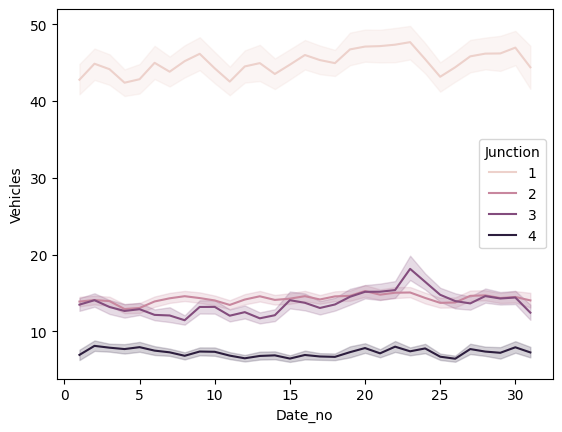

In [4]:
sns.lineplot(x=data['Date_no'], y="Vehicles", data=data, hue='Junction')


In [5]:
data = data[(data['Junction'] == 1)]
def Normalize(df,col):
  average = df[col].mean()
  stdev = df[col].std()
  df_normalized = (df[col] - average) / stdev
  df_normalized = df_normalized.to_frame()
  return df_normalized, average, stdev

def Difference(df, col, interval):
  diff = []
  for i in range(interval):
    diff.append(None)

  for i in range(interval, len(df)):
    value = df[col][i] - df[col][i - interval]
    diff.append(value)
  return diff

In [6]:
df_N, av, std = Normalize(data, "Vehicles")
Diff = Difference(df_N, col="Vehicles", interval=(24*7)) #taking a week's diffrence
df_N.columns = ["Norm"]
df_N["Diff"]= Diff
df_N = df_N[24*7:]
df = df_N["Diff"].dropna()
df = df.to_frame()
df.head()

,Diff
168,-0.086925
169,0.130387
170,0.043462
171,0.043462
172,0.043462


In [7]:
df.shape

(14424, 1)

In [8]:
def Split_data(df):
  training_size = int(len(df)*0.80)
  data_len = len(df)
  train, test = df[0:training_size], df[training_size:data_len]
  train, test = train.values.reshape(-1,1), test.values.reshape(-1,1)
  return train, test

df_train, df_test = Split_data(df)

In [9]:
def TnF(df):
 end_len = len(df)
 X = []
 Y = []
 steps = 32
 for i in range(steps, end_len):
  X.append(df[i - steps:i, 0])
  Y.append(df[i, 0])
 X, Y = np.array(X), np.array(Y)
 return X ,Y

def FeatureFixShape(train, test):
  train = np.reshape(train, (train.shape[0], train.shape[1], 1))
  test = np.reshape(test, (test.shape[0], test.shape[1],1))
  return train, test

X_train, y_train = TnF(df_train)
X_test, y_test = TnF(df_test)
X_train, X_test = FeatureFixShape(X_train, X_test)



In [10]:
X_train, X_test = FeatureFixShape(X_train, X_test)
from sklearn.metrics import mean_absolute_error
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    decay_rate=0.9
)
def MLP_model(X_Train, y_Train, X_Test, y_Test):
  X_Train = np.squeeze(X_Train)
  X_Test = np.squeeze(X_Test)
  early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
  model = Sequential()
  model.add(Dense(100, activation='relu', input_dim=X_train.shape[1]))
  model.add(Dropout(0.2))
  model.add(Dense(20, activation='relu', input_dim=X_Train.shape[1]))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
  model.fit(X_Train, y_Train, validation_data=(X_test, y_test), epochs=50, batch_size=120, callbacks=[early_stopping])
  pred_MLP = model.predict(X_Test)
  return  pred_MLP

In [28]:
def RMSE_value(test,predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("the root mean squared error is{}.".format(rmse))
  return rmse


def MAE_Value(test,predicted):
  mae = mean_absolute_error(test, predicted)
  print("the MAE is {}.".format(mae))
  return mae


def PredictionsPlote(test, predicted, m):
  plt.figure(figsize=(12,5))
  plt.plot(test, color=colors[m],label="True Value", alpha=0.5)
  plt.plot(predicted,label="Predicted Values")
  plt.title("Traffic Prediction Vs True values")
  plt.xlabel("DateTime")
  plt.ylabel("Number of Vehicles")
  plt.legend()
  plt.show

In [12]:
pred_MLP = MLP_model(X_train, y_train, X_test, y_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0787 - val_loss: 0.0753
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0588 - val_loss: 0.0665
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0558 - val_loss: 0.0643
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0544 - val_loss: 0.0620
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0527 - val_loss: 0.0613
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0509 - val_loss: 0.0595
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0512 - val_loss: 0.0589
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0499 - val_loss: 0.0589
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0494 - val_loss: 0.0579
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0497 - val_loss: 0.0577
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0484 - val_loss: 0.0571
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0493 - val_loss: 0.0575


the root mean squared error is0.23793389647076557.
the MAE is 0.1715443640076641.


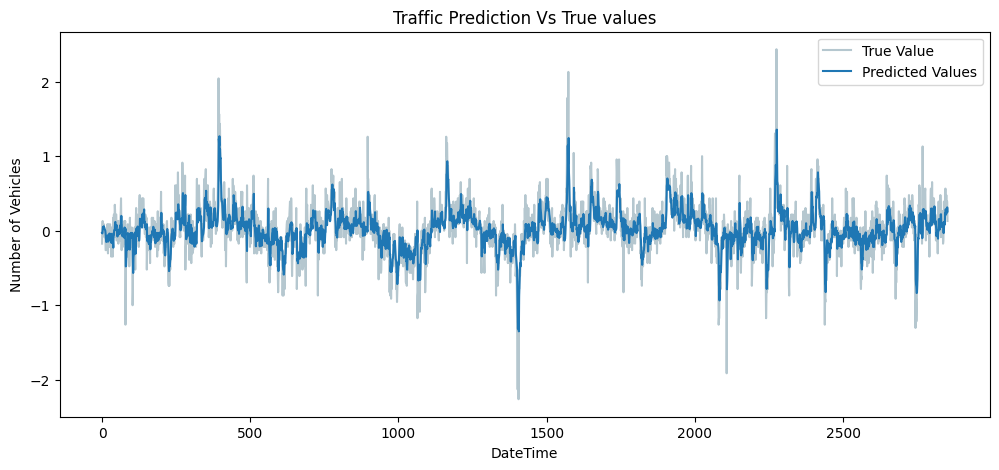

In [29]:
colors = ["#6D91A1","#74B3CE1","#536D7A","#3E535B"]
RMSE_MLP = RMSE_value(y_test, pred_MLP)
MAE_MLP = MAE_Value(y_test, pred_MLP)
PredictionsPlote(y_test, pred_MLP, 0)

In [30]:

def inverse_difference(last_ob, value):
    inversed = value + last_ob
    return inversed

def Sub_Plots(df_1, df_2,title,m):
    fig, axes = plt.subplots(1, 2, figsize=(18,4), sharey=True)
    fig.suptitle(title)

    pl_1=sns.lineplot(ax=axes[0],data=df_1,color=colors[m])
    axes[0].set(ylabel ="Prediction")

    pl_2=sns.lineplot(ax=axes[1],data=df_2["Vehicles"],color="#3E535B")
    axes[1].set(ylabel ="Original")

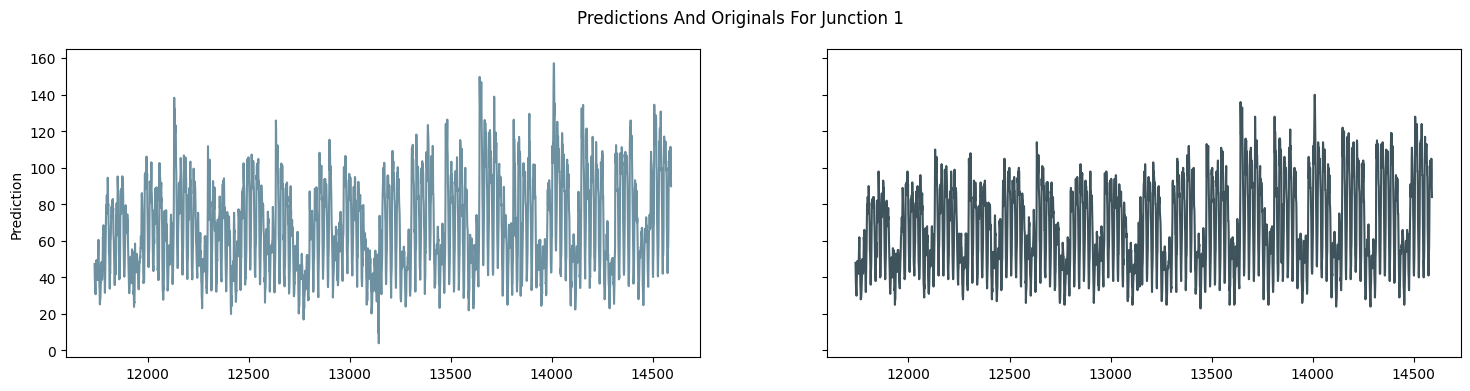

In [32]:
recover = df_N.Norm[-2854:-1].to_frame()
recover["Pred"]= globals()[f"pred_MLP"]
Transform_reverssed = inverse_difference(recover.Norm, recover.Pred).to_frame()
Transform_reverssed.columns = ["Pred_Normed"]
Final_Pred = (Transform_reverssed.values* std) + av
Transform_reverssed["Pred_Final"] = Final_Pred
Sub_Plots(Transform_reverssed["Pred_Final"], data[-2854:-1],"Predictions And Originals For Junction 1", 0)

In [33]:
def GRU_model(X_Train, y_Train, X_Test, y_Test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True)
    #callback delta 0.01 may interrupt the learning.

    #The GRU model
    model = Sequential()
    model.add(GRU(units=100, return_sequences=True, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(GRU(units=20, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    #Compiling the model
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train,y_Train, validation_data=(X_Test, y_Test), epochs=50, batch_size=120,callbacks=[early_stopping])
    pred_GRU= model.predict(X_Test)
    return pred_GRU

In [36]:

def LSTM_model(X_Train, y_Train, X_Test, y_Test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001,patience=10, restore_best_weights=True)

    #The LSTM model
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(LSTM(units=20, input_shape=(X_Train.shape[1],1), activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    #Compiling the model
    model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
    model.fit(X_Train,y_Train, validation_data=(X_Test, y_Test), epochs=50, batch_size=120,callbacks=[early_stopping])
    pred_LSTM = model.predict(X_Test)
    return pred_LSTM

In [37]:
Pred_GRU = GRU_model(X_train,y_train,X_test,y_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - loss: 0.0566 - val_loss: 0.0627
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0484 - val_loss: 0.0628
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0485 - val_loss: 0.0593
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0469 - val_loss: 0.0584
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0456 - val_loss: 0.0579
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0460 - val_loss: 0.0572
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0462 - val_loss: 0.0568
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0450 - val_loss: 0.0566
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0450 - val_loss: 0.0563
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0445 - val_loss: 0.0563
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0446 - val_loss: 0.0561
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0445 - v

the root mean squared error is0.23585895420674924.
the MAE is 0.17075406412637023.


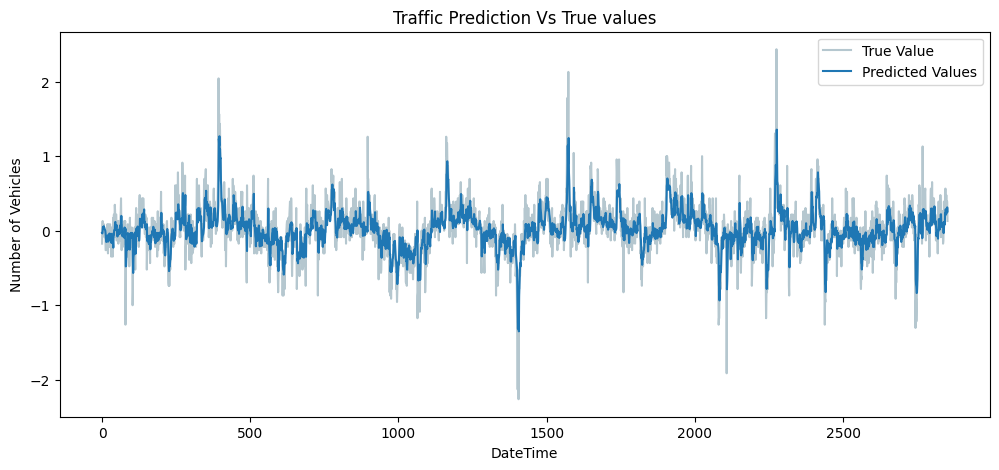

In [41]:
RMSE_GRU = RMSE_value(y_test, Pred_GRU)
MAE_GRU = MAE_Value(y_test, Pred_GRU)
PredictionsPlote(y_test, pred_MLP, 0)

In [42]:
Pred_LSTM = LSTM_model(X_train,y_train,X_test, y_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0736 - val_loss: 0.0840
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0611 - val_loss: 0.0797
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0587 - val_loss: 0.0769
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0566 - val_loss: 0.0740
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 0.0550 - val_loss: 0.0722
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0541 - val_loss: 0.0706
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0537 - val_loss: 0.0694
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0528 - val_loss: 0.0680
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0523 - val_loss: 0.0670
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0508 - val_loss: 0.0659
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.0507 - val_loss: 0.0650
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0506 - va

the root mean squared error is0.23585895420674924.
the MAE is 0.17075406412637023.


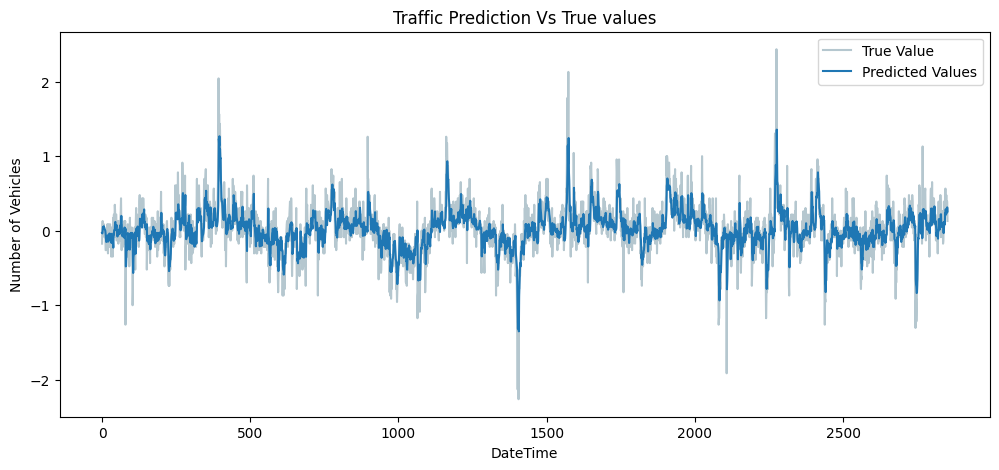

In [44]:
RMSE_GRU = RMSE_value(y_test, Pred_GRU)
MAE_GRU = MAE_Value(y_test, Pred_GRU)
PredictionsPlote(y_test, pred_MLP, 0)